##  **Hour 1: Problem Framing, Data Wrangling & Exploration**

**Problem statement:** Students will be introduced to the problem of classifying customer support queries for an e-commerce system. They will set up their environment and explore a dataset containing raw customer messages such as return requests, refund inquiries, and product issues.

#### **Objective**: Load, clean, and explore the customer support dataset. Understand the problem of intent classification.

##### **Setup**: Install libraries. Import them.

##### **Load Data from Hugging Face:** Use the datasets library to load the Bitext dataset directly.

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
# Load the dataset
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
# Convert to pandas dataframe
df = pd.DataFrame(dataset['train'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

##### **Initial Exploration**

##### **Question for students**: What columns do we have?.
##### What is our target variable?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [ ]:
df.tail()

,flags,instruction,category,intent,response
26867,BL,I am waiting for a rebate of {{Refund Amount}}...,REFUND,track_refund,Thank you for sharing your situation regarding...
26868,BIL,how to see if there is anything wrong with my ...,REFUND,track_refund,Ensuring the accuracy of your restitution is o...
26869,BLQZ,I'm waiting for a reimbjrsement of {{Currency ...,REFUND,track_refund,"Firstly, I genuinely understand the importance..."
26870,BL,I don't know what to do to see my reimbursemen...,REFUND,track_refund,I've understood you're unsure about how to che...
26871,BL,I need to know if there is anything new on the...,REFUND,track_refund,It's completely understandable that you want t...


In [ ]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,shiping to {{Delivery City}},ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


##### **Data Cleaning Exercise:**
1. Check for and handle missing values.
2. Check for duplicate utterances.

In [ ]:
df.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#### **Task-1**: Remove duplicate instructions, keeping the first occurrence.

In [ ]:
df.duplicated(subset=["instruction"]).sum()

np.int64(2237)

In [ ]:
df.duplicated(subset=["flags"]).sum()

np.int64(26478)

In [ ]:
df.duplicated(subset=["intent"]).sum()

np.int64(26845)

In [ ]:
df.duplicated(subset=["response"]).sum()

np.int64(2)

In [ ]:
df.duplicated(subset=["category"]).sum()

np.int64(26861)

In [ ]:
df[df.duplicated(subset=["instruction"], keep=False)]

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
6,BCLN,"I can no longer afford order {{Order Number}},...",ORDER,cancel_order,I pick up what you're putting down that you're...
7,BL,I am trying to cancel purchase {{Order Number}},ORDER,cancel_order,I've understood that you're seeking assistance...
8,BL,I have got to cancel purchase {{Order Number}},ORDER,cancel_order,I'm sensitive to the fact that you're seeking ...
...,...,...,...,...,...
26859,BL,I expect a compensation of {{Currency Symbol}}...,REFUND,track_refund,We really appreciate your expectation of a com...
26861,BLQ,i expect a restitution of {{Refund Amount}} do...,REFUND,track_refund,"I'm on the same page, the importance of receiv..."
26865,BLQ,I'm waiting for a rebate of {{Refund Amount}} ...,REFUND,track_refund,I'm conscious of the reality that you have bee...
26867,BL,I am waiting for a rebate of {{Refund Amount}}...,REFUND,track_refund,Thank you for sharing your situation regarding...


In [ ]:
dups = df[df.duplicated(subset=["instruction", "intent"], keep=False)]
dups.sort_values(by=["instruction"]).head(10)

,flags,instruction,category,intent,response
25557,BK,ETA of order {{Order Number}},ORDER,track_order,Thank you for your query! I understand that yo...
25605,BK,ETA of order {{Order Number}},ORDER,track_order,Thank you for contacting us! I'm here to assis...
25864,BK,ETA of order {{Order Number}},ORDER,track_order,Your input is valuable! I'm picking up that yo...
25320,BK,ETA of order {{Order Number}},ORDER,track_order,It's great to hear from you! I can see that yo...
25447,BK,ETA of order {{Order Number}},ORDER,track_order,We're all ears! I'm tuned into the idea that y...
24880,BKLQ,ETA of purchase {{Order Number}},ORDER,track_order,Thank you for reaching out! I'm here to assist...
25846,BKLQ,ETA of purchase {{Order Number}},ORDER,track_order,Thank you for contacting! I certainly recogniz...
636,B,I am trying to cancel order {{Order Number}},ORDER,cancel_order,I've realized that you are trying to cancel yo...
235,B,I am trying to cancel order {{Order Number}},ORDER,cancel_order,I've been informed that you're currently attem...
418,BLZ,I am trying to cancel purchaes {{Order Number}},ORDER,cancel_order,I hear you loud and clear that you're trying t...


##### **Exploratory Data Analysis (EDA):**

Plot the distribution of intents



##### **Question:** Is the dataset balanced? Why is this important for model training?

Analyze the tags column. What are the most common linguistic phenomena? (e.g., colloquial, interrogative).

In [ ]:
# Unique items in the df
df.nunique()

,0
flags,394
instruction,24635
category,11
intent,27
response,26870


In [ ]:
df["category"].value_counts()


,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


In [ ]:
df["intent"].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


In [ ]:
df["flags"].value_counts()

,count
flags,
BL,5212
BLQ,2467
BIL,2138
BLM,1297
BILQ,1057
...,...
BIPQWZ,1
BENQWZ,1
BPQWZ,1


In [ ]:
pd.crosstab(df["category"], df["intent"], normalize="index").round(3)

intent,cancel_order,change_order,change_shipping_address,check_cancellation_fee,check_invoice,check_payment_methods,check_refund_policy,complaint,contact_customer_service,contact_human_agent,...,newsletter_subscription,payment_issue,place_order,recover_password,registration_problems,review,set_up_shipping_address,switch_account,track_order,track_refund
category,,,,,,,,,,,,,,,,,,,,,
ACCOUNT,0.00,0.00,0.000,0.0,0.0,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.00,0.166,0.167,0.000,0.000,0.167,0.000,0.000
CANCEL,0.00,0.00,0.000,1.0,0.0,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
CONTACT,0.00,0.00,0.000,0.0,0.0,0.0,0.000,0.000,0.5,0.5,...,0.0,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
DELIVERY,0.00,0.00,0.000,0.0,0.0,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
FEEDBACK,0.00,0.00,0.000,0.0,0.0,0.0,0.000,0.501,0.0,0.0,...,0.0,0.0,0.00,0.000,0.000,0.499,0.000,0.000,0.000,0.000
INVOICE,0.00,0.00,0.000,0.0,0.5,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ORDER,0.25,0.25,0.000,0.0,0.0,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.25,0.000,0.000,0.000,0.000,0.000,0.249,0.000
PAYMENT,0.00,0.00,0.000,0.0,0.0,0.5,0.000,0.000,0.0,0.0,...,0.0,0.5,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
REFUND,0.00,0.00,0.000,0.0,0.0,0.0,0.333,0.000,0.0,0.0,...,0.0,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.334


In [ ]:
placeholders = [
    "{{Order Number}}",
    "{{Online Company Portal Info}}",
    "{{Online Order Interaction}}",
    "{{Customer Support Hours}}",
    "{{Customer Support Phone Number}}",
    "{{Website URL}}",
]

for ph in placeholders:
    print(ph, "in instruction:", df["instruction"].str.contains(ph, regex=False).sum())
    print(ph, "in response:   ", df["response"].str.contains(ph, regex=False).sum())
    print()

{{Order Number}} in instruction: 2907
{{Order Number}} in response:    4036

{{Online Company Portal Info}} in instruction: 0
{{Online Company Portal Info}} in response:    1054

{{Online Order Interaction}} in instruction: 0
{{Online Order Interaction}} in response:    1014

{{Customer Support Hours}} in instruction: 0
{{Customer Support Hours}} in response:    2322

{{Customer Support Phone Number}} in instruction: 0
{{Customer Support Phone Number}} in response:    2633

{{Website URL}} in instruction: 0
{{Website URL}} in response:    2524



### **Basic Plots to gain insight from the data**

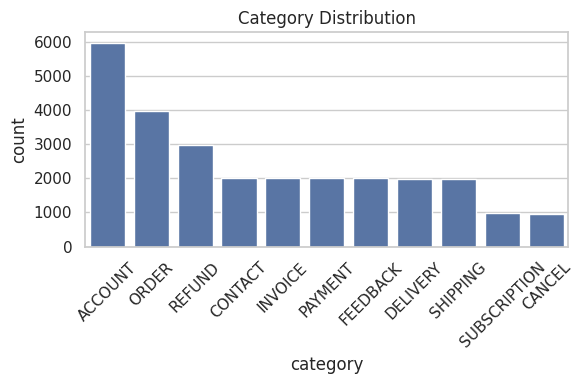

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.title("Category Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

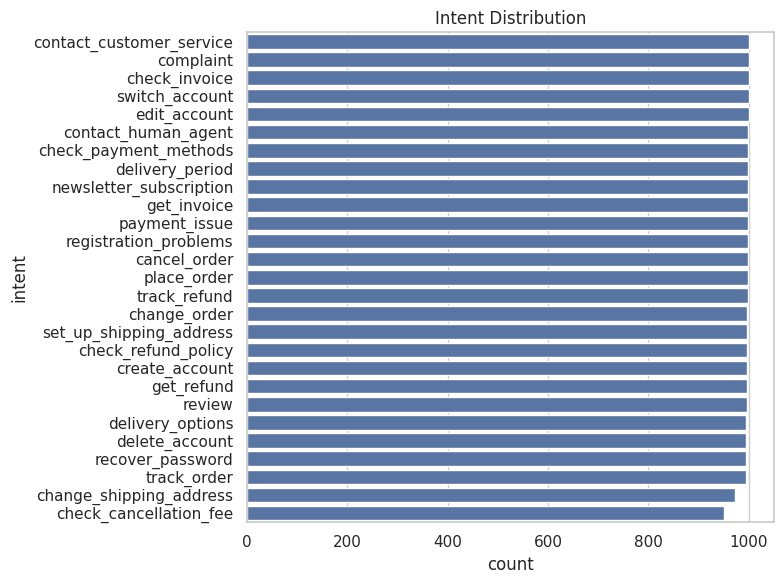

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    y="intent",
    order=df["intent"].value_counts().index
)
plt.title("Intent Distribution")
plt.tight_layout()
plt.show()

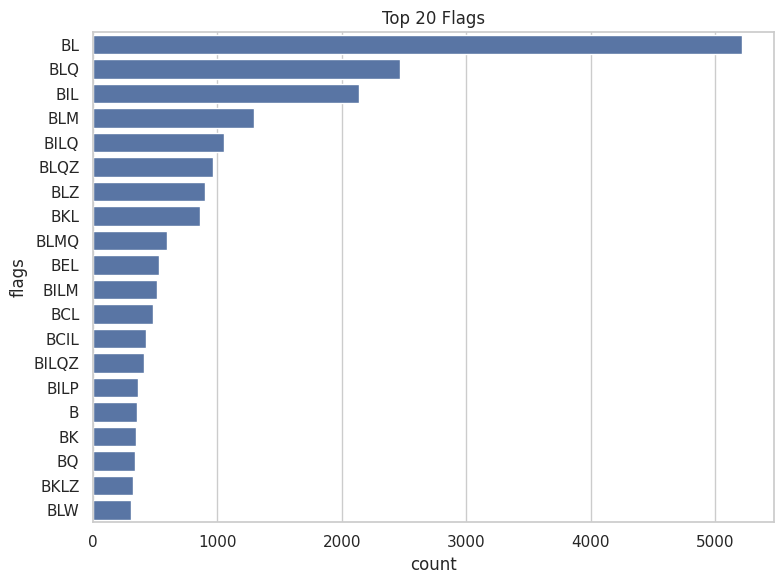

In [ ]:
top_n = 20
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    y="flags",
    order=df["flags"].value_counts().iloc[:top_n].index
)
plt.title(f"Top {top_n} Flags")
plt.tight_layout()
plt.show()

####  **Text length distributions**
First compute lengths and plotting of the data

In [ ]:
df["instruction_len"] = df["instruction"].str.len()
df["response_len"] = df["response"].str.len()

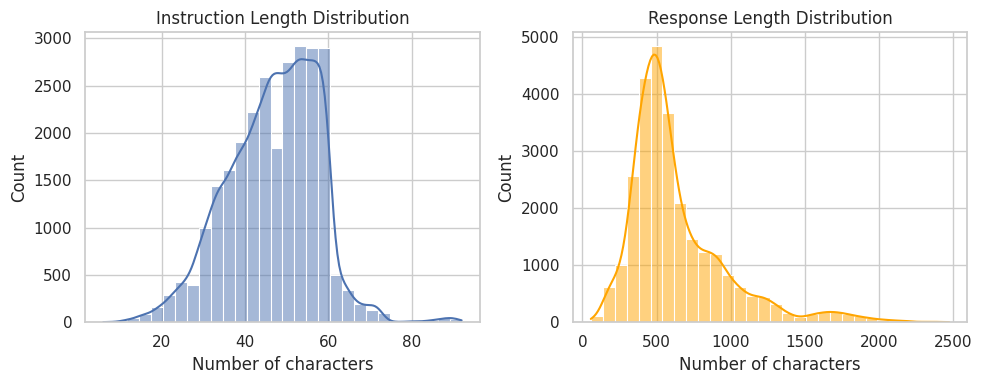

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["instruction_len"], bins=30, kde=True)
plt.title("Instruction Length Distribution")
plt.xlabel("Number of characters")

plt.subplot(1, 2, 2)
sns.histplot(df["response_len"], bins=30, kde=True, color="orange")
plt.title("Response Length Distribution")
plt.xlabel("Number of characters")

plt.tight_layout()
plt.show()

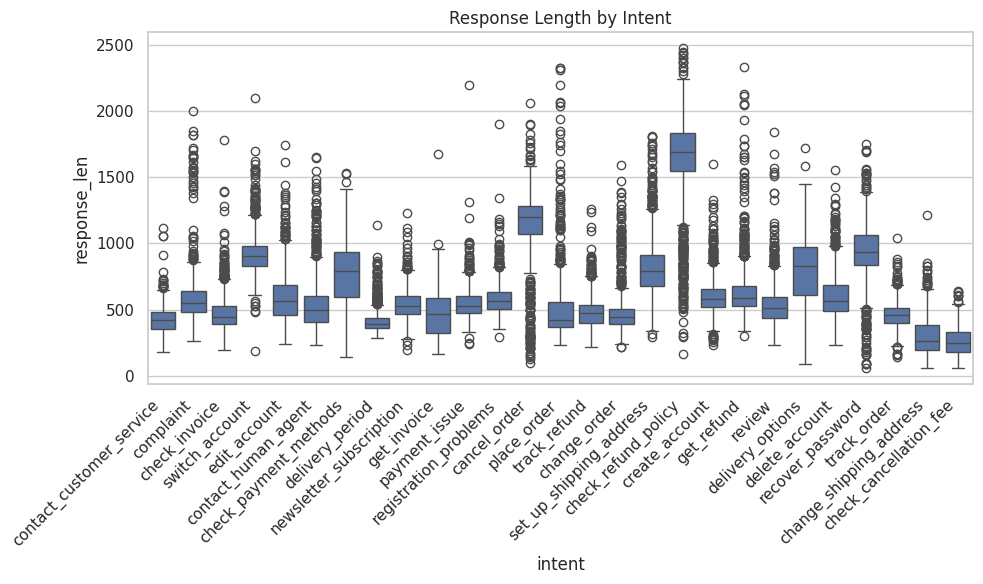

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="intent",
    y="response_len",
    order=df["intent"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Response Length by Intent")
plt.tight_layout()
plt.show()

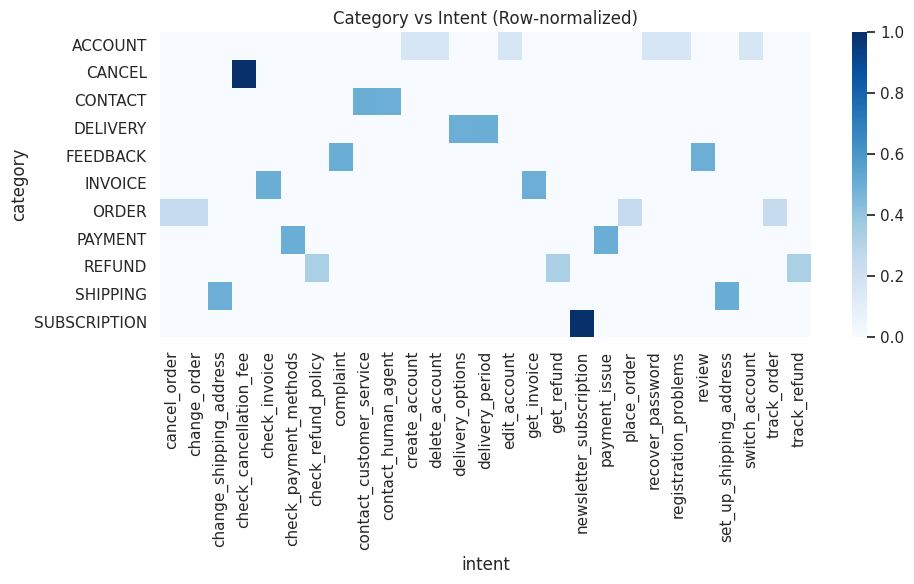

In [ ]:
ct_norm = pd.crosstab(df["category"], df["intent"], normalize="index")
plt.figure(figsize=(10, 6))
sns.heatmap(ct_norm, cmap="Blues")
plt.title("Category vs Intent (Row-normalized)")
plt.tight_layout()
plt.show()

### **Mini-Challenge Hour-1:** Find the top 5 most common words in the instruction column. What does this tell you?

#### To answer this mini‑challenge, let us attempt two things:

1. Show how to compute the top 5 most common words in instruction
2. Interpret what those words tell you about your dataset

#### **How to compute the top 5 most common words**

1. Normalize text (lowercase)
2. Remove punctuation / braces
3. Split into words (tokens)
4. Optionally remove stopwords (“the”, “and”, “to”, etc.)
5. Count word frequencies and show the top 5

In [ ]:
import re
from collections import Counter
import pandas as pd

# 1. Make a copy of instruction column and lowercase it
instructions = df["instruction"].str.lower().fillna("")

# 2. Simple cleaning function: remove punctuation except curly braces (optional)
def clean_text(text):
    # remove punctuation except curly braces (so {{order number}} stays)
    text = re.sub(r"[^\w\s{}]", " ", text)   # keep letters, digits, _, space, {, }
    # collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

instructions_clean = instructions.apply(clean_text)

# 3. Tokenize (split on whitespace)
tokens = instructions_clean.str.split()

# 4. Flatten list of token lists into a single list
all_words = [word for sublist in tokens for word in sublist]

len(all_words), all_words[:20]  # to quickly inspect

(235316,
 ['question',
  'about',
  'cancelling',
  'order',
  '{{order',
  'number}}',
  'i',
  'have',
  'a',
  'question',
  'about',
  'cancelling',
  'oorder',
  '{{order',
  'number}}',
  'i',
  'need',
  'help',
  'cancelling',
  'puchase'])

In [ ]:
# Remove stopwords
stopwords = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those",
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having",
    "do", "does", "did", "doing",
    "a", "an", "the",
    "and", "but", "if", "or", "because", "as", "until", "while",
    "of", "at", "by", "for", "with", "about", "against",
    "between", "into", "through", "during", "before", "after",
    "above", "below", "to", "from", "up", "down", "in", "out",
    "on", "off", "over", "under",
    "again", "further", "then", "once",
    "here", "there", "when", "where", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other", "some", "such",
    "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very",
    "can", "will", "just", "don", "should", "now"
}

content_words = [w for w in all_words if w not in stopwords]

In [ ]:
# Count and display 5 words
# If you want without stopwords:
word_counts = Counter(content_words)

# If you want with stopwords, use:
# word_counts = Counter(all_words)

top_5 = word_counts.most_common(5)
top_5

[('help', 6319),
 ('need', 4059),
 ('account', 3567),
 ('want', 3110),
 ('assistance', 3005)]

In [ ]:
top_words_df = pd.DataFrame(top_5, columns=["word", "count"])
top_words_df

,word,count
0,help,6319
1,need,4059
2,account,3567
3,want,3110
4,assistance,3005


### **Summary of Mini Challenge Hour-1**

1. The dataset is support-focused: words like help, need, and assistance show users are explicitly asking for help rather than stating facts or giving commands.
2. It’s user-centric and request-driven: want and need indicate many utterances are framed as personal needs (“I need…”, “I want…”), typical of customer service or helpdesk scenarios.
3. “Account” is a core entity: its high frequency suggests a large portion of queries are about account-related issues (login, settings, security, billing linked to accounts, etc.), not just orders.
4. Overall, "Instructions" look like natural user help requests about their accounts and related actions, making this a good training set for an assistant that handles customer support / account management.

###  ***End of Hour -1***

---
